In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sn

In [3]:
from scipy import stats

In [4]:
dataset = pd.read_csv('titanic.csv')
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
fare_values = dataset.loc[dataset['Fare'].notnull(), 'Fare'].values
print(fare_values.shape)

(891,)


In [6]:
mean_fare = np.round(np.mean(fare_values))
print(f"Średnia opłata to {mean_fare}")

Średnia opłata to 32.0


In [7]:
median_fare = np.median(fare_values).round(2)
print(f"Mediana opłat to {median_fare}")

Mediana opłat to 14.45


In [8]:
mode_fare = stats.mode(fare_values)
print(mode_fare)
print(f"Najwięcej {mode_fare.count} pasażerów zapłaciło {mode_fare.mode}")

ModeResult(mode=np.float64(8.05), count=np.int64(43))
Najwięcej 43 pasażerów zapłaciło 8.05


In [9]:
q0 = np.quantile(fare_values, 0.0)
q1 = np.quantile(fare_values, 0.25).round(2)
q3 = np.quantile(fare_values, 0.75).round(2)
q4 = np.quantile(fare_values, 1.0).round(2)
print(f'Q0: {q0}')
print(f'Q1: {q1}')
print(f'Q2: {median_fare}')
print(f'Q3: {q3}')
print(f'Q4: {q4}')
print(f"Najniższa opłata to {q0}, zaś najwyższa to {q4}. 25% pasażerów dokonało opłaty nie wyższej niż {q1}, a 75% pasażerów zapłaciło nie więcej niż {q3}.")

Q0: 0.0
Q1: 7.91
Q2: 14.45
Q3: 31.0
Q4: 512.33
Najniższa opłata to 0.0, zaś najwyższa to 512.33. 25% pasażerów dokonało opłaty nie wyższej niż 7.91, a 75% pasażerów zapłaciło nie więcej niż 31.0.


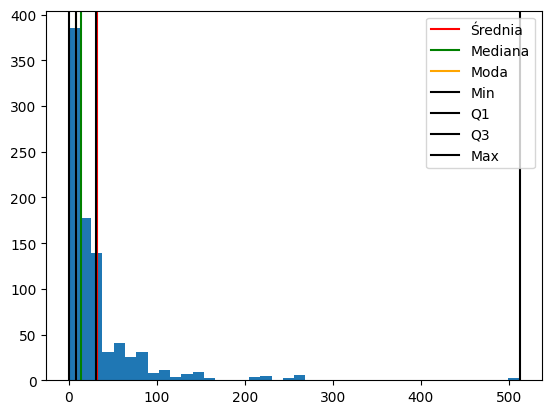

In [10]:
plt.hist(fare_values, bins=40)
plt.axvline(x = mean_fare, color='red', label = 'Średnia')
plt.axvline(x = median_fare, color='green', label = 'Mediana')
plt.axvline(x = mode_fare[0], color='orange', label = 'Moda')
plt.axvline(x = q0, color='black', label = 'Min')
plt.axvline(x = q1, color='black', label = 'Q1')
plt.axvline(x = q3, color='black', label = 'Q3')
plt.axvline(x = q4, color='black', label = 'Max')
plt.legend(loc='upper right')
plt.show()

In [11]:
range_fare = (max(fare_values) - min(fare_values)).round(2)
print(f"Zakres danych: {range_fare}")

Zakres danych: 512.33


In [12]:
iqr = q3 - q1
print(f"Rozstęp międzykwartylowy: {iqr}")

Rozstęp międzykwartylowy: 23.09


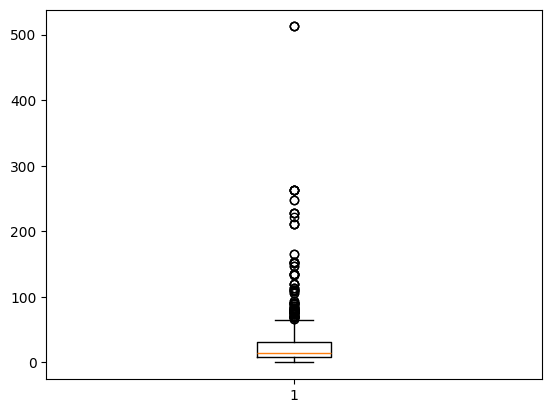

In [13]:
plt.boxplot(fare_values)
plt.show()